<a href="https://colab.research.google.com/github/yuvipaloozie/Regime-Aware-Sector-Trading/blob/main/notebooks/Sector_Rotation_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- REVISED CELL 1: Universe Ingestion + Safe Haven Asset (TLT) ---
!pip install yfinance pandas numpy scikit-learn xgboost quantstats

import yfinance as yf
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print("1. Loading Macro Regime Vector...")
try:
    regime_df = pd.read_csv('oos_macro_regime_vector_weekly (1).csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    raise FileNotFoundError("Ensure 'oos_macro_regime_vector_weekly.csv' is in the working directory.")

print("2. Downloading Sector ETFs, Safe Haven, and Macro Benchmarks...")
# 11 Sectors + Proxies + SPY + ^TNX + TLT (Safe Haven)
TICKERS = ['XLK', 'XLE', 'XLF', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLC', 'XLRE', 'VOX', 'VNQ', 'SPY', '^TNX', 'TLT']

# Adjusted to 2003 to accommodate TLT inception (July 2002)
START_DATE = '2003-01-01'
END_DATE = '2026-05-01'

raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE)['Close'].ffill()

raw_data['XLC'] = raw_data['XLC'].fillna(raw_data['VOX'])
raw_data['XLRE'] = raw_data['XLRE'].fillna(raw_data['VNQ'])

clean_etfs = raw_data[['XLK', 'XLE', 'XLF', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLC', 'XLRE']]
spy_close = raw_data['SPY']
tnx_close = raw_data['^TNX']
tlt_close = raw_data['TLT'] # The Safe Haven Asset

print("3. Resampling to Weekly (Friday Close)...")
weekly_etfs = clean_etfs.resample('W-FRI').last()
weekly_spy = spy_close.resample('W-FRI').last()
weekly_tnx = tnx_close.resample('W-FRI').last()
weekly_tlt = tlt_close.resample('W-FRI').last()

print(f"Data ingestion complete. Weekly ETF Shape: {weekly_etfs.shape}")

1. Loading Macro Regime Vector...
2. Downloading Sector ETFs, Safe Haven, and Macro Benchmarks...


[*********************100%***********************]  16 of 16 completed


3. Resampling to Weekly (Friday Close)...
Data ingestion complete. Weekly ETF Shape: (1218, 11)


In [ ]:
# --- REVISED CELL 2: Orthogonal Macro-Sensitivity Feature Engineering ---
print("Engineering Orthogonal Features (Momentum, Volatility, Beta, Rate Sensitivity)...")

# 1. Calculate base weekly log returns and differences
weekly_rets = np.log(weekly_etfs / weekly_etfs.shift(1))
spy_rets = np.log(weekly_spy / weekly_spy.shift(1))
tnx_diff = weekly_tnx.diff(1) # Yields are already percentages, use arithmetic difference

# 2. Build the Wide Feature DataFrames
# A. Momentum (1-Week Reversion, 13-Week Trend)
mom_1w = weekly_rets
mom_13w = np.log(weekly_etfs / weekly_etfs.shift(13))

# B. Volatility (13-Week Annualized)
vol_13w = weekly_rets.rolling(13).std() * np.sqrt(52)

# C. Market Beta (26-Week Rolling)
# Beta = Covariance(Sector, SPY) / Variance(SPY)
spy_var_26w = spy_rets.rolling(26).var()
beta_26w = pd.DataFrame(index=weekly_rets.index, columns=weekly_rets.columns)
for col in weekly_rets.columns:
    beta_26w[col] = weekly_rets[col].rolling(26).cov(spy_rets) / spy_var_26w

# D. Rate Sensitivity (26-Week Rolling Correlation to 10Yr Yield)
corr_tnx_26w = pd.DataFrame(index=weekly_rets.index, columns=weekly_rets.columns)
for col in weekly_rets.columns:
    corr_tnx_26w[col] = weekly_rets[col].rolling(26).corr(tnx_diff)

# 3. Stack and Merge into Master DataFrame
def stack_feature(df, feature_name):
    stacked = df.unstack().reset_index()
    stacked.columns = ['Ticker', 'Date', feature_name]
    return stacked.set_index(['Date', 'Ticker'])

df_master = stack_feature(weekly_etfs, 'Close')
df_master = df_master.join(stack_feature(mom_1w, 'Mom_1W'))
df_master = df_master.join(stack_feature(mom_13w, 'Mom_13W'))
df_master = df_master.join(stack_feature(vol_13w, 'Vol_13W'))
df_master = df_master.join(stack_feature(beta_26w, 'Beta_SPY_26W'))
df_master = df_master.join(stack_feature(corr_tnx_26w, 'Corr_TNX_26W'))

# Merge Macro Regimes (Shifted by 1 WEEK)
regime_shifted = regime_df.shift(1).fillna(method='bfill')
df_master = df_master.join(regime_shifted, on='Date', how='inner')

# 4. Target Orthogonalization (4-Week Forward Alpha)
df_master['Log_Close'] = np.log(df_master['Close'])
df_master['Raw_Fwd_4W'] = df_master.groupby('Ticker')['Log_Close'].shift(-4) - df_master['Log_Close']
df_master['Target_Alpha_4W'] = df_master['Raw_Fwd_4W'] - df_master.groupby('Date')['Raw_Fwd_4W'].transform('mean')

# 5. Cross-Sectional Z-Scoring (Daily normalization across the 11 sectors)
features_to_scale = ['Mom_1W', 'Mom_13W', 'Vol_13W', 'Beta_SPY_26W', 'Corr_TNX_26W']

def cross_sectional_zscore(group):
    for col in features_to_scale:
        mean = group[col].mean()
        std = group[col].std() if group[col].std() != 0 else 1.0
        group[f'{col}_Z'] = (group[col] - mean) / std
    return group

df_master = df_master.groupby(level='Date', group_keys=False).apply(cross_sectional_zscore)

# Flag inference rows and drop warm-up NaNs
df_master['Is_Training_Row'] = df_master['Target_Alpha_4W'].notna()
df_master = df_master.dropna(subset=['Corr_TNX_26W_Z'])

ml_features = [f"{col}_Z" for col in features_to_scale] + ['Smoothed_Regime']

print("\nOrthogonal Feature Array Ready for ML:")
for feature in ml_features:
    print(f" - {feature}")

Engineering Orthogonal Features (Momentum, Volatility, Beta, Rate Sensitivity)...

Orthogonal Feature Array Ready for ML:
 - Mom_1W_Z
 - Mom_13W_Z
 - Vol_13W_Z
 - Beta_SPY_26W_Z
 - Corr_TNX_26W_Z
 - Smoothed_Regime


Generating correlation heatmap for input features...


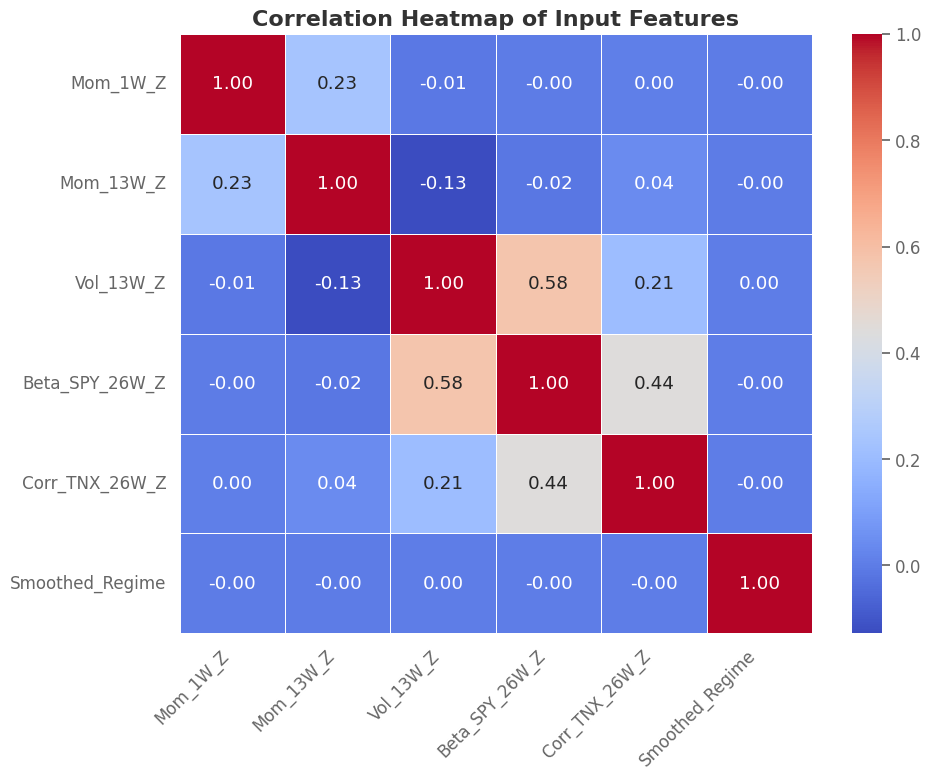

In [ ]:
# --- CELL 3.6: Correlation Heatmap of Input Features ---
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating correlation heatmap for input features...")

# Ensure 'features' list is available from previous cells

# Select the relevant features from df_master
feature_df = df_master[ml_features]

# Calculate the correlation matrix
correlation_matrix = feature_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Input Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# --- CELL 3: Purged Walk-Forward XGBoost Ranking Engine ---
from tqdm.auto import tqdm
import xgboost as xgb

print("Initializing Expanding Walk-Forward XGBoost LambdaMART Engine...")

# Define features (Exclude Risk_Scalar from training; it is an execution overlay)
features = ml_features
# Filter out inference rows (the final 4 weeks that have no target yet)
df_trainable = df_master[df_master['Is_Training_Row'] == True].copy()

# Ensure Regime is treated as an integer for optimal tree splitting
df_trainable['Smoothed_Regime'] = df_trainable['Smoothed_Regime'].astype(int)

# Explicitly sort the MultiIndex to prevent UnsortedIndexError during slicing
df_trainable = df_trainable.sort_index()

dates = df_trainable.index.get_level_values('Date').unique().sort_values()

# Walk-Forward Parameters
MIN_TRAIN_WEEKS = 260  # 5 Years of initial training data to capture multiple macro states
PURGE_WEEKS = 4        # Prevent lookahead bias from the 4-week forward target
STEP_WEEKS = 4         # Re-train the model every 4 weeks (~1 month)

xgb_params = {
    'objective': 'rank:pairwise',
    'learning_rate': 0.05,
    'max_depth': 3,          # Shallow trees to prevent overfitting cross-sectional noise
    'n_estimators': 150,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

predictions = []
feature_importance_history = []

# Expanding Window Loop
for t_idx in tqdm(range(MIN_TRAIN_WEEKS + PURGE_WEEKS, len(dates), STEP_WEEKS), desc="Walk-Forward Folds"):
    train_cutoff_date = dates[t_idx - PURGE_WEEKS]
    test_start_date = dates[t_idx]
    test_end_date = dates[min(t_idx + STEP_WEEKS - 1, len(dates) - 1)]

    train_data = df_trainable.loc[:train_cutoff_date]
    test_data = df_trainable.loc[test_start_date:test_end_date]

    if test_data.empty:
        continue

    X_train = train_data[features]
    y_train = train_data['Target_Alpha_4W']

    # XGBRanker requires a 'group' array indicating the number of items per ranking query (11 sectors per week)
    train_groups = train_data.groupby(level='Date').size().values

    model = xgb.XGBRanker(**xgb_params)
    model.fit(X_train, y_train, group=train_groups, verbose=False)

    # Store feature importances for interpretability
    feature_importance_history.append(model.feature_importances_)

    # Predict Out-Of-Sample
    X_test = test_data[features]
    test_preds = test_data[['Raw_Fwd_4W', 'Smoothed_Regime', 'Risk_Scalar']].copy()
    test_preds['ML_Rank_Score'] = model.predict(X_test)

    predictions.append(test_preds)

oos_results = pd.concat(predictions)
print(f"\nSUCCESS: Out-of-Sample Predictions Generated ({len(oos_results)} single-sector ranking events).")


Initializing Expanding Walk-Forward XGBoost LambdaMART Engine...


Walk-Forward Folds:   0%|          | 0/231 [00:00<?, ?it/s]


SUCCESS: Out-of-Sample Predictions Generated (10164 single-sector ranking events).


Extracting Global Feature Importances...


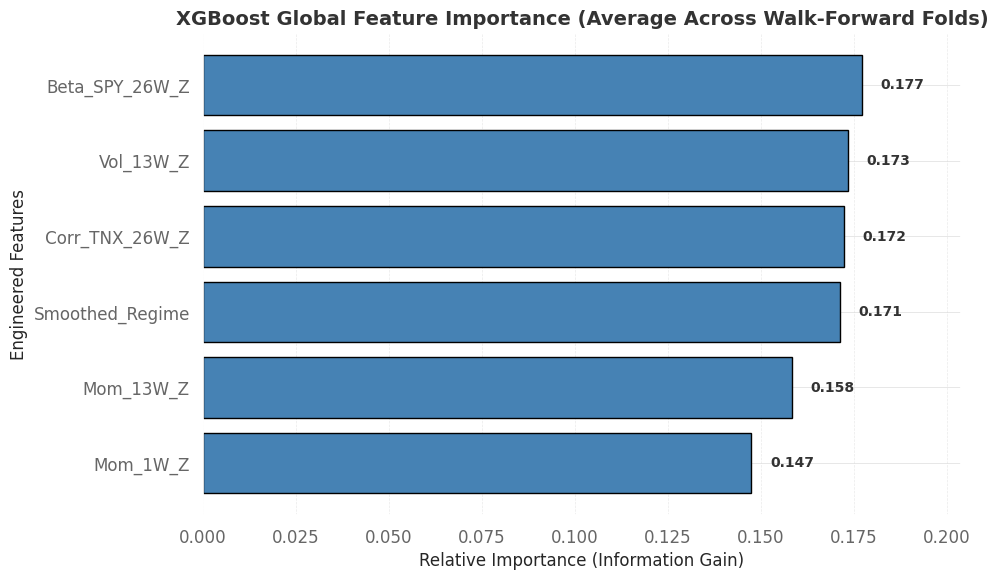

In [ ]:
# --- CELL 3.5: Machine Learning Interpretability (Global Feature Importance) ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Extracting Global Feature Importances...")

# Calculate average importance across all walk-forward folds
avg_importances = np.mean(feature_importance_history, axis=0)

importance_df = pd.DataFrame({
    'Feature': features,
    'Average_Importance_Gain': avg_importances
}).sort_values(by='Average_Importance_Gain', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Average_Importance_Gain'],
                color='steelblue', edgecolor='black')

for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.3f}",
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.title('XGBoost Global Feature Importance (Average Across Walk-Forward Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Information Gain)', fontsize=12)
plt.ylabel('Engineered Features', fontsize=12)
plt.xlim(0, importance_df['Average_Importance_Gain'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Initializing Grand Unified Execution Grid (ML Models x Portfolio Configs)...
             GRAND UNIFIED EXECUTION MATRIX (ML TUNE x HYSTERESIS)
                        ML_Model  Top_N  Ann. Sharpe  Total Return (%)  Max Drawdown (%)  Avg 4Wk Turnover (%)
Configuration                                                                                                 
[Baseline] Top_2_Buf_1  Baseline      2         0.41            449.68            -33.51                110.91
[Baseline] Top_2_Buf_2  Baseline      2         0.41            452.29            -33.51                102.08
[Baseline] Top_3_Buf_2  Baseline      3         0.39            426.49            -29.16                 95.27
[Baseline] Top_3_Buf_1  Baseline      3         0.35            370.07            -29.76                103.87

---> OPTIMAL PIPELINE: [Baseline] Top_2_Buf_1 (Sharpe: 0.41)
---> Optimal returns saved to memory for Tearsheet generation.


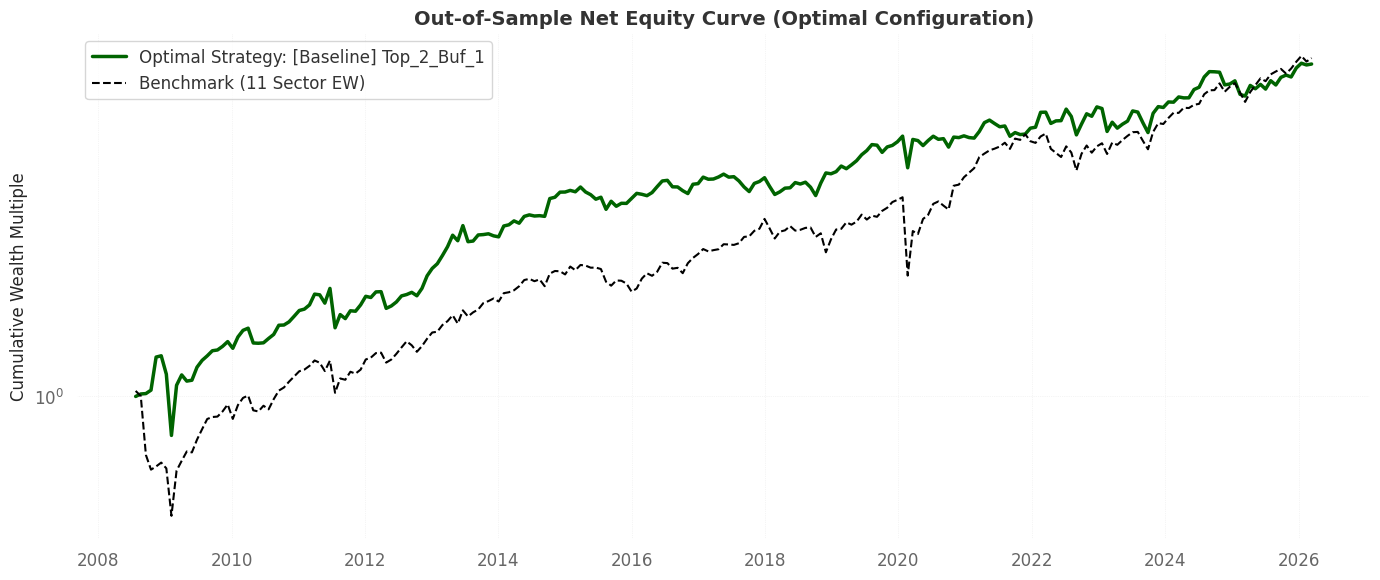

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Initializing Grand Unified Execution Grid (ML Models x Portfolio Configs)...")

# 1. Ensure Target Returns are prepped
if 'Fwd_Ret_4W' not in df_master.columns:
    df_master['Fwd_Ret_4W'] = df_master.groupby('Ticker')['Close'].shift(-4) / df_master['Close'] - 1
if 'TLT_Fwd_Ret_4W' not in globals():
    tlt_fwd_ret_4w = weekly_tlt.shift(-4) / weekly_tlt - 1

TOP_N_OPTIONS = [2, 3]
HOLD_BUFFERS = [1, 2]
SLIPPAGE_BPS = 0.0005
RISK_FREE_RATE = 0.04 / 13

results_log = []
best_sharpe = -999
best_equity_curve = None
best_config_name = ""

# Initialize tuning_results with the oos_results generated from the previous cell.
# This assumes a single "Baseline" model for now, as consolidation was mentioned.
tuning_results = {'Baseline': oos_results}

# 2. Outer Loop: Iterate through the ML Models generated in Cell 5
for model_name, model_oos_preds in tuning_results.items():

    execution_df = model_oos_preds[['ML_Rank_Score', 'Smoothed_Regime', 'Risk_Scalar']].copy()
    execution_df = execution_df.join(df_master[['Fwd_Ret_4W']], how='inner')
    execution_df = execution_df.dropna(subset=['Fwd_Ret_4W'])

    dates = execution_df.index.get_level_values('Date').unique().sort_values()
    tickers = execution_df.index.get_level_values('Ticker').unique()
    rebalance_dates = dates[::4]

    # 3. Inner Loop: Iterate through Portfolio Execution parameters
    for top_n, buffer in itertools.product(TOP_N_OPTIONS, HOLD_BUFFERS):

        matrix_cols = list(tickers) + ['TLT']
        weight_matrix = pd.DataFrame(0.0, index=rebalance_dates, columns=matrix_cols)
        current_holdings = []

        for date in rebalance_dates:
            day_data = execution_df.xs(date, level='Date')
            day_data['Rank'] = day_data['ML_Rank_Score'].rank(ascending=False)
            risk_scalar = day_data['Risk_Scalar'].iloc[0] if not day_data.empty else 0.0

            # Hysteresis Base Equity Selection
            retained_holdings = [t for t in current_holdings if t in day_data.index and day_data.loc[t, 'Rank'] <= (top_n + buffer)]
            slots_to_fill = top_n - len(retained_holdings)
            available_buys = day_data[~day_data.index.isin(retained_holdings)].sort_values('Rank')
            new_buys = available_buys.head(slots_to_fill).index.tolist()

            current_holdings = retained_holdings + new_buys

            # Capital Allocation: Equities vs. TLT
            if risk_scalar > 0.0 and len(current_holdings) > 0:
                equity_weights = (1.0 / len(current_holdings)) * risk_scalar
                weight_matrix.loc[date, current_holdings] = equity_weights

            tlt_weight = 1.0 - risk_scalar
            if tlt_weight > 0.0:
                weight_matrix.loc[date, 'TLT'] = tlt_weight

        # 4. Calculate Friction and Net Returns
        target_weights = weight_matrix.shift(1).fillna(0.0)
        turnover = target_weights.diff().abs().sum(axis=1)

        return_matrix = df_master['Fwd_Ret_4W'].unstack().reindex(index=rebalance_dates).fillna(0.0)
        tlt_returns = tlt_fwd_ret_4w.reindex(rebalance_dates).fillna(0.0)
        return_matrix['TLT'] = tlt_returns

        gross_returns = (target_weights * return_matrix).sum(axis=1)
        net_returns = gross_returns - (turnover * SLIPPAGE_BPS)

        # 5. Calculate Metrics
        excess_returns = net_returns - RISK_FREE_RATE
        sharpe_ratio = np.sqrt(13) * (excess_returns.mean() / excess_returns.std()) if excess_returns.std() > 0 else 0
        cum_return = (1 + net_returns).cumprod()
        total_return_pct = (cum_return.iloc[-1] - 1) * 100
        max_dd_pct = ((cum_return - cum_return.cummax()) / cum_return.cummax()).min() * 100
        avg_turnover_pct = turnover.mean() * 100

        config_name = f"[{model_name}] Top_{top_n}_Buf_{buffer}"

        # Save the absolute best model for global scope (for QuantStats)
        if sharpe_ratio > best_sharpe:
            best_sharpe = sharpe_ratio
            best_equity_curve = cum_return
            best_config_name = config_name
            # Export the best net returns to the global environment for Cell 7
            globals()['optimal_net_returns'] = net_returns
            globals()['optimal_weight_matrix'] = weight_matrix

        results_log.append({
            'Configuration': config_name,
            'ML_Model': model_name,
            'Top_N': top_n,
            'Ann. Sharpe': sharpe_ratio,
            'Total Return (%)': total_return_pct,
            'Max Drawdown (%)': max_dd_pct,
            'Avg 4Wk Turnover (%)': avg_turnover_pct
        })

# 6. Display the Master Results Matrix
results_df = pd.DataFrame(results_log).sort_values(by='Ann. Sharpe', ascending=False).set_index('Configuration')

print("="*95)
print("             GRAND UNIFIED EXECUTION MATRIX (ML TUNE x HYSTERESIS)")
print("="*95)
print(results_df[['ML_Model', 'Top_N', 'Ann. Sharpe', 'Total Return (%)', 'Max Drawdown (%)', 'Avg 4Wk Turnover (%)']].round(2).to_string())
print("="*95)
print(f"\n---> OPTIMAL PIPELINE: {best_config_name} (Sharpe: {best_sharpe:.2f})")
print("---> Optimal returns saved to memory for Tearsheet generation.")

# 7. Visualization of the Best Equity Curve vs Benchmark
benchmark_returns = df_master['Fwd_Ret_4W'].unstack().reindex(index=rebalance_dates).fillna(0.0).mean(axis=1)
cum_benchmark = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(best_equity_curve.index, best_equity_curve, label=f'Optimal Strategy: {best_config_name}', color='darkgreen', linewidth=2.5)
plt.plot(cum_benchmark.index, cum_benchmark, label='Benchmark (11 Sector EW)', color='black', linestyle='--', linewidth=1.5)

plt.title('Out-of-Sample Net Equity Curve (Optimal Configuration)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Wealth Multiple', fontsize=12)
plt.yscale('log')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1600x700 with 0 Axes>

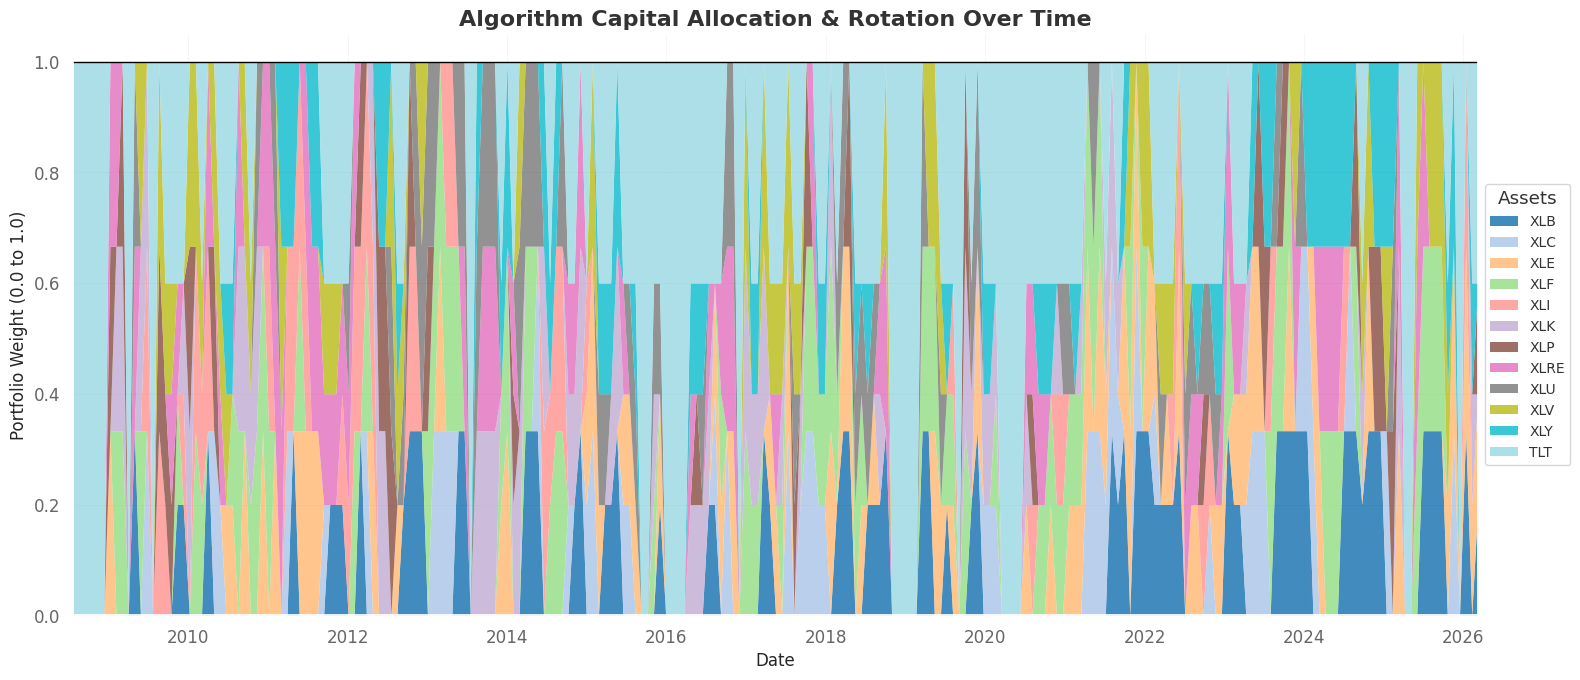

In [ ]:
# --- CELL 6: Capital Rotation Timechart ---
import matplotlib.pyplot as plt

# Assuming 'weight_matrix' is currently holding your BEST configuration from Cell 4
# Ensure the index is datetime format
weight_matrix.index = pd.to_datetime(weight_matrix.index)

plt.figure(figsize=(16, 7))

# Plot the stacked area chart
# colormap 'tab20' ensures distinctly visible colors for the 11 sectors + TLT
ax = weight_matrix.plot.area(figsize=(16, 7), cmap='tab20', alpha=0.85, linewidth=0)

# Formatting
plt.title('Algorithm Capital Allocation & Rotation Over Time', fontsize=16, fontweight='bold')
plt.ylabel('Portfolio Weight (0.0 to 1.0)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.margins(x=0, y=0)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10, title="Assets")

# Highlight Crisis Periods where TLT spikes
plt.axhline(1.0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# --- CELL 7: Institutional Performance Tearsheet (QuantStats) ---
!pip install quantstats

import quantstats as qs
import pandas as pd

print("Generating Institutional Quant Tearsheet...")

# 1. Format the Strategy Returns (net_returns from Cell 4)
strat_series = pd.Series(net_returns, index=pd.to_datetime(net_returns.index))
strat_series.name = 'ML Rotation Strategy (Net)'

# 2. Format the Benchmark Returns (Equal Weight Sector Benchmark from Cell 4)
benchmark_series = pd.Series(benchmark_returns, index=pd.to_datetime(benchmark_returns.index))
benchmark_series.name = 'Benchmark (11 Sector EW)'

# Strip timezones and drop NaNs
strat_series.index = strat_series.index.tz_localize(None)
benchmark_series.index = benchmark_series.index.tz_localize(None)
strat_series = strat_series.dropna()
benchmark_series = benchmark_series.dropna()

# 3. Export the Interactive HTML Report
html_filename = "ML_Sector_Rotation_Tearsheet.html"
qs.reports.html(strat_series, benchmark=benchmark_series,
                output=html_filename,
                title='Regime-Conditioned Sector Rotation')

print(f"SUCCESS: Full interactive tearsheet exported to '{html_filename}'.")

Generating Institutional Quant Tearsheet...


SUCCESS: Full interactive tearsheet exported to 'ML_Sector_Rotation_Tearsheet.html'.
